In [247]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore")


In [248]:
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")

In [249]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [250]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [251]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [252]:
df.shape

(1200, 13)

In [253]:
print(df.isnull().sum())

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64


In [254]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

In [255]:
print(df["platform_usage"].value_counts())

platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64


In [256]:
df = pd.get_dummies(df, columns=["platform_usage"], dtype=int)

In [257]:
df.head()


,age,gender,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,platform_usage_Both,platform_usage_Instagram,platform_usage_TikTok
0,14,male,7.9,7.4,2.9,3.01,1.5,low,2,2,1,0,0,1,0
1,19,female,1.9,8.0,2.9,3.22,0.8,high,8,1,10,0,0,0,1
2,17,female,1.3,7.6,0.5,3.92,0.0,high,2,4,2,0,0,1,0
3,15,male,7.4,6.9,1.6,3.48,0.8,medium,1,7,9,0,0,0,1
4,15,female,4.7,4.9,3.0,2.37,1.4,medium,3,5,2,0,1,0,0


In [258]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["social_interaction_level"] = le.fit_transform(df["social_interaction_level"])

In [259]:
df.head(10)


,age,gender,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,platform_usage_Both,platform_usage_Instagram,platform_usage_TikTok
0,14,male,7.9,7.4,2.9,3.01,1.5,1,2,2,1,0,0,1,0
1,19,female,1.9,8.0,2.9,3.22,0.8,0,8,1,10,0,0,0,1
2,17,female,1.3,7.6,0.5,3.92,0.0,0,2,4,2,0,0,1,0
3,15,male,7.4,6.9,1.6,3.48,0.8,2,1,7,9,0,0,0,1
4,15,female,4.7,4.9,3.0,2.37,1.4,2,3,5,2,0,1,0,0
5,19,female,7.4,4.4,2.4,2.63,0.6,0,3,5,7,0,1,0,0
6,18,female,2.5,6.4,2.4,2.63,0.7,1,2,2,5,0,0,1,0
7,16,male,4.0,4.2,0.5,2.40,1.3,1,6,10,5,0,1,0,0
8,19,female,3.3,5.0,2.1,2.04,0.9,0,1,10,9,0,0,0,1
9,15,male,1.9,4.9,1.5,3.77,1.1,0,1,1,4,0,0,0,1


In [260]:
print(df["gender"].value_counts())

gender
male      615
female    585
Name: count, dtype: int64


In [261]:
df["gender"] = df["gender"].map({"male": 1,"female": 0}).astype(int)

In [262]:
df.head()


,age,gender,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,platform_usage_Both,platform_usage_Instagram,platform_usage_TikTok
0,14,1,7.9,7.4,2.9,3.01,1.5,1,2,2,1,0,0,1,0
1,19,0,1.9,8.0,2.9,3.22,0.8,0,8,1,10,0,0,0,1
2,17,0,1.3,7.6,0.5,3.92,0.0,0,2,4,2,0,0,1,0
3,15,1,7.4,6.9,1.6,3.48,0.8,2,1,7,9,0,0,0,1
4,15,0,4.7,4.9,3.0,2.37,1.4,2,3,5,2,0,1,0,0


In [263]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'social_interaction_level', 'stress_level', 'anxiety_level',
       'addiction_level', 'depression_label', 'platform_usage_Both',
       'platform_usage_Instagram', 'platform_usage_TikTok'],
      dtype='object')

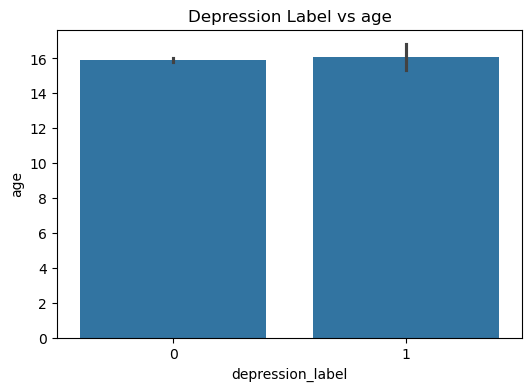

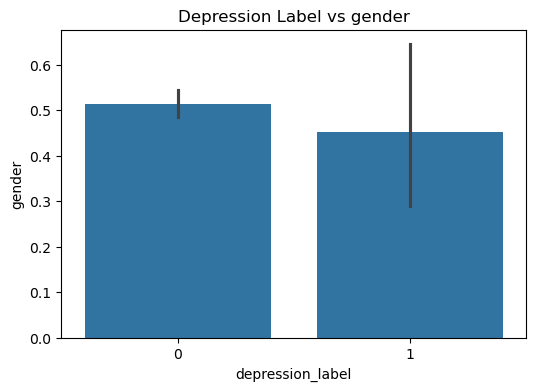

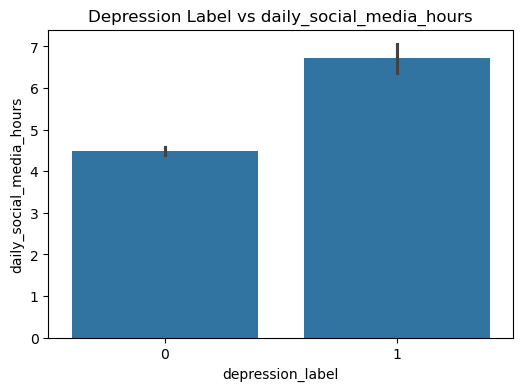

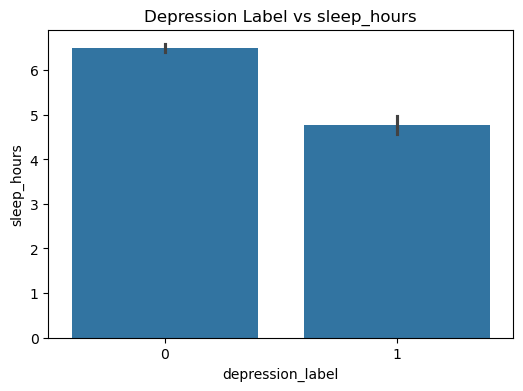

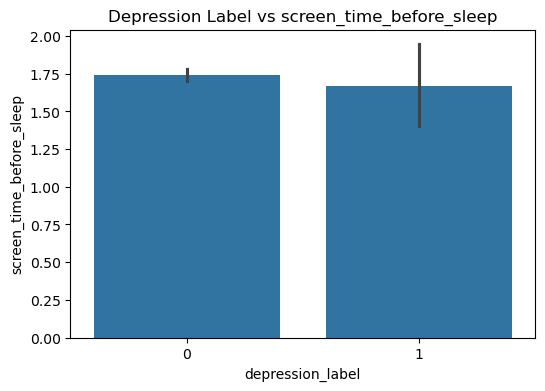

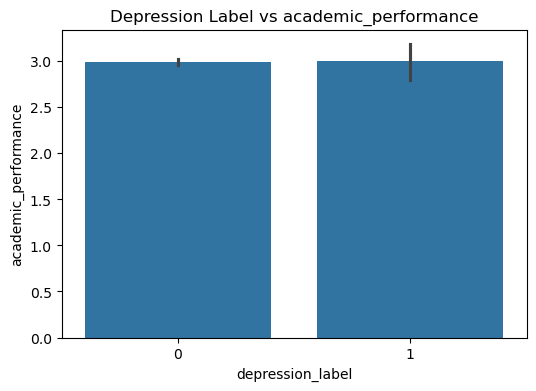

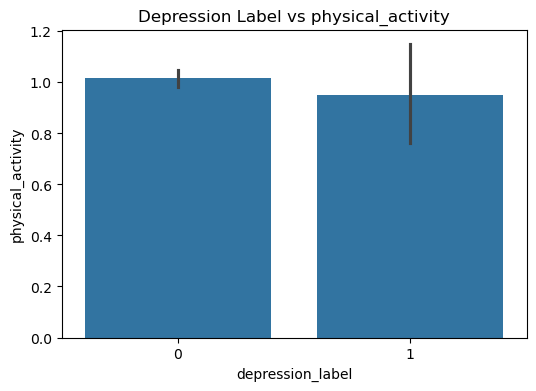

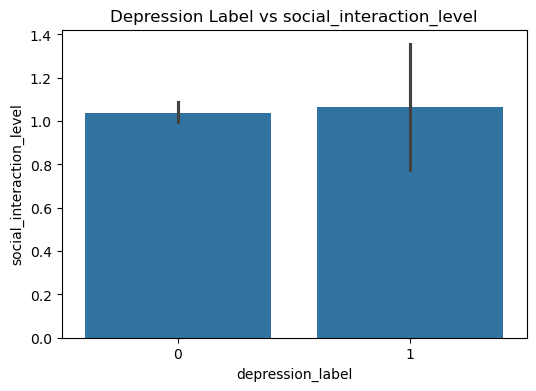

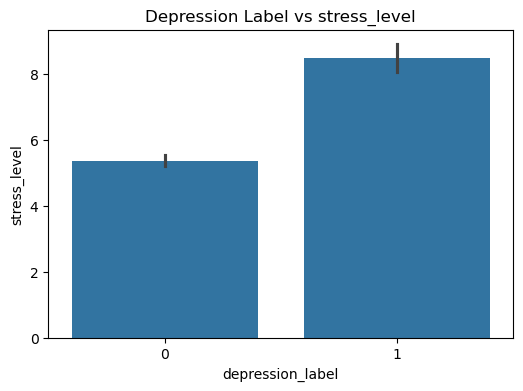

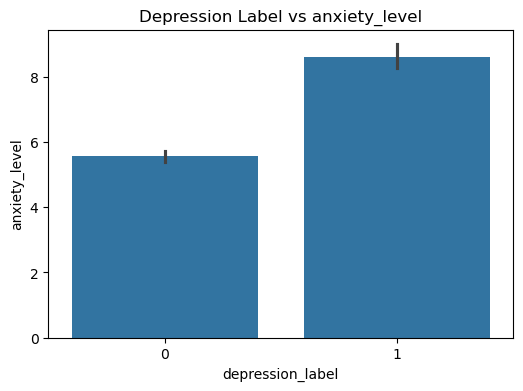

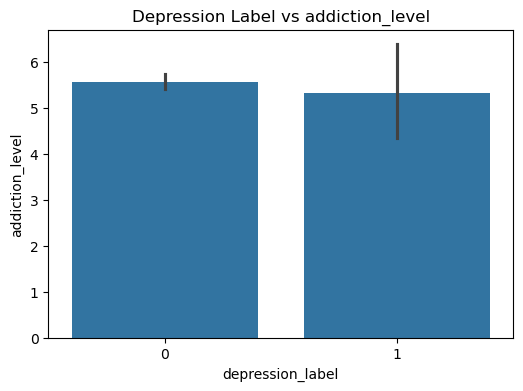

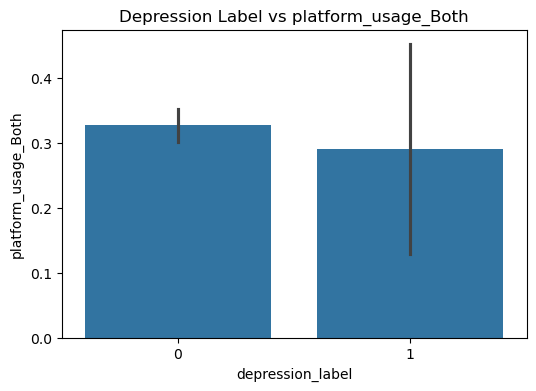

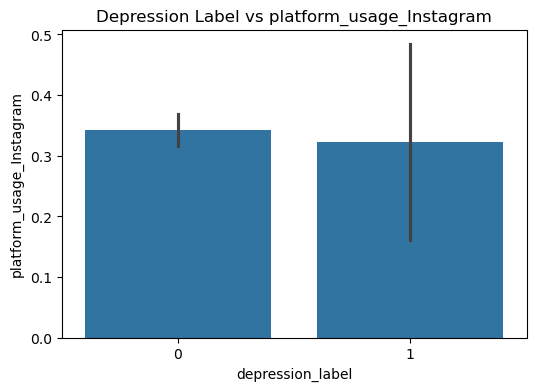

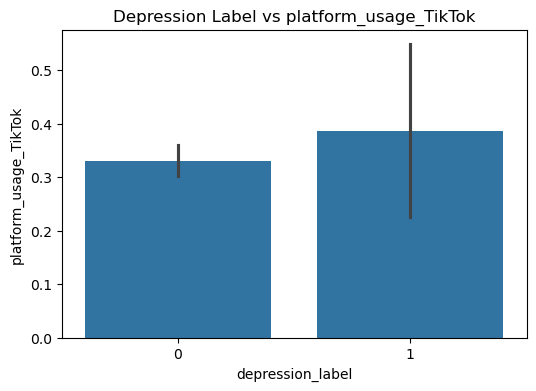

In [264]:
for col in df.columns:
    if col != "depression_label":
        plt.figure(figsize=(6,4))
        sns.barplot(x="depression_label", y=col, data=df)
        plt.title(f"Depression Label vs {col}")
        plt.show()

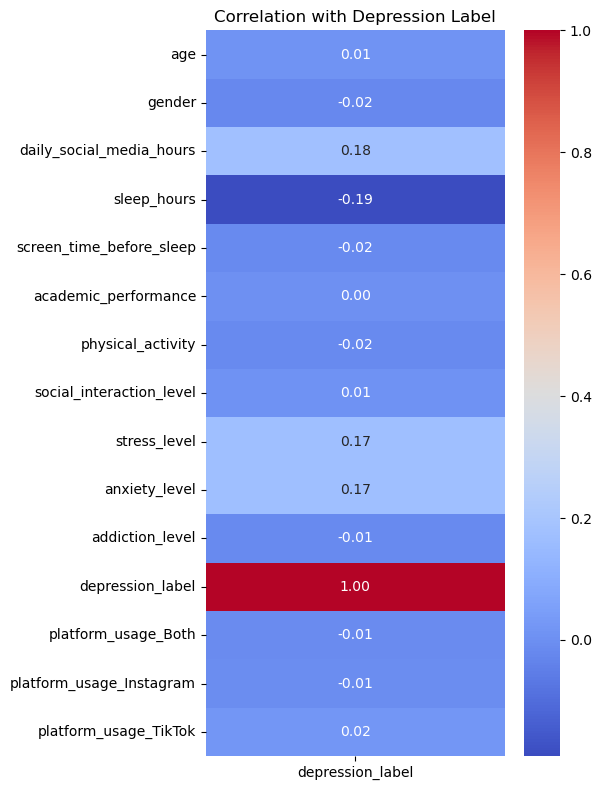

In [265]:
corr = df.corr(numeric_only=True)[["depression_label"]]

plt.figure(figsize=(6, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation with Depression Label")
plt.tight_layout()
plt.show()

In [266]:
from sklearn.model_selection import train_test_split
X = df.drop("depression_label", axis=1)
y = df["depression_label"]

In [267]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [268]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train) 
X_test_scaled= scaler.transform(X_test)        

In [269]:
from sklearn.linear_model import LogisticRegression
model_1 = LogisticRegression(max_iter=(1000))
model_1.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [270]:
y_pred_1 = model_1.predict(X_test_scaled)

In [271]:
y_pred_1

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [272]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy_1:", accuracy)

Accuracy_1: 0.9772727272727273


In [273]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[387   0]
 [  9   0]]


By using Decision Tree 

In [274]:
from sklearn.tree import DecisionTreeClassifier

In [275]:
model_2 = DecisionTreeClassifier(random_state=100)

In [276]:
model_2.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,100
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [277]:
y_pred_2 = model_2.predict(X_test)

In [278]:
y_pred_2

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [279]:
print("Accuracy_2:", accuracy_score(y_test, y_pred))

Accuracy_2: 0.9772727272727273


In [280]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[387   0]
 [  9   0]]


By using Random Forest

In [281]:
from sklearn.ensemble import RandomForestClassifier

In [282]:
model_3 = RandomForestClassifier(n_estimators=100,random_state=42)

In [283]:
model_3.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [284]:
y_pred_3 = model_3.predict(X_test)

In [285]:
y_pred_3

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [286]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy_3:", accuracy)

Accuracy_3: 0.9772727272727273


In [287]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[387   0]
 [  9   0]]


In [288]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       387
           1       0.00      0.00      0.00         9

    accuracy                           0.98       396
   macro avg       0.49      0.50      0.49       396
weighted avg       0.96      0.98      0.97       396



By using KNN

In [289]:
from sklearn.neighbors import KNeighborsClassifier

In [290]:
model_4 = KNeighborsClassifier(n_neighbors=5)

In [291]:
model_4.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [292]:
y_pred_4 = model_4.predict(X_test_scaled)

In [293]:
y_pred_4

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [294]:
print("Accuracy_4:", accuracy_score(y_test, y_pred))

Accuracy_4: 0.9772727272727273


In [295]:
print(confusion_matrix(y_test, y_pred))

[[387   0]
 [  9   0]]


In [296]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       387
           1       0.00      0.00      0.00         9

    accuracy                           0.98       396
   macro avg       0.49      0.50      0.49       396
weighted avg       0.96      0.98      0.97       396



By using SVM

In [297]:
from sklearn.svm import SVC

In [298]:
model_5 = SVC(kernel='rbf', random_state=42)

In [299]:
model_5.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [300]:
y_pred_5 = model_5.predict(X_test_scaled)

In [301]:
print("Accuracy_5:", accuracy_score(y_test, y_pred))

Accuracy_5: 0.9772727272727273


In [302]:
print(confusion_matrix(y_test, y_pred))

[[387   0]
 [  9   0]]


In [303]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       387
           1       0.00      0.00      0.00         9

    accuracy                           0.98       396
   macro avg       0.49      0.50      0.49       396
weighted avg       0.96      0.98      0.97       396



cross validation 

In [304]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.975      0.975      0.975      0.975      0.97083333]
Mean accuracy: 0.9741666666666667


In [305]:
import joblib

joblib.dump(model, "logistic_regression_model.pkl")
joblib.dump(scaler, "scaler.pkl")  # Save if you used StandardScaler

['scaler.pkl']

In [307]:
print(X.columns.tolist())

['age', 'gender', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'platform_usage_Both', 'platform_usage_Instagram', 'platform_usage_TikTok']
